In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv("datasets/SMSSpamCollection", sep='\t', names=['label', 'text'])
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### Separate the input and output variables

In [3]:
x = df['text']
y = df['label']

#### Explore the data 

In [4]:
set(y)

{'ham', 'spam'}

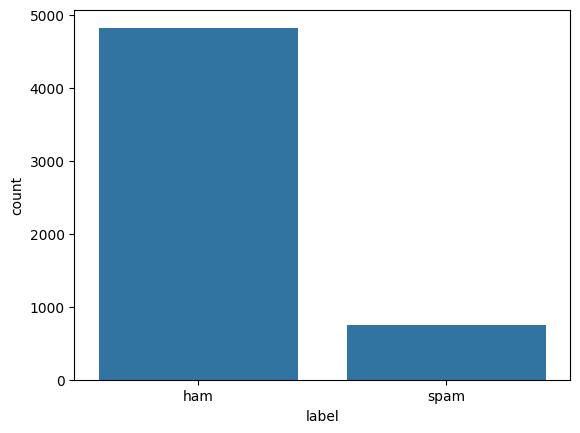

In [5]:
sns.countplot(x=y);

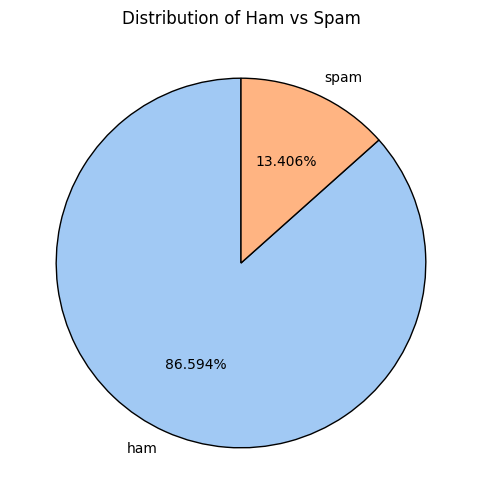

In [6]:
label_counts = df['label'].value_counts()
colors = sns.color_palette('pastel')[0:len(label_counts)]

plt.figure(figsize=(6, 6))
plt.pie(label_counts, 
        labels=label_counts.index, 
        autopct='%3.3f%%', 
        startangle=90, 
        colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Distribution of Ham vs Spam')
plt.show()

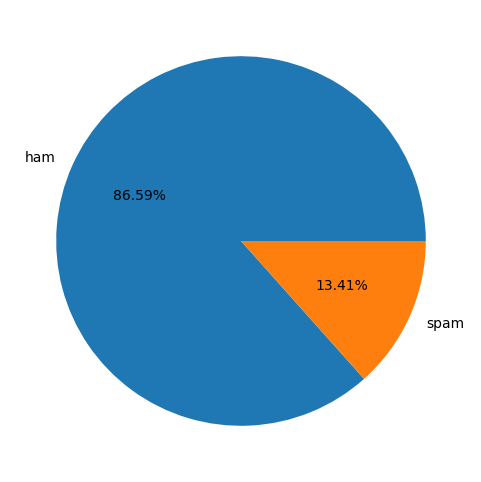

In [7]:
plt.figure(figsize=(6, 6))
plt.pie(y.value_counts(), labels=y.value_counts().index, autopct='%2.2f%%');

### Data Preprocessing

#### Data Cleaning

In [8]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer, PorterStemmer
from nltk import pos_tag

In [9]:
# Sample text data
sent = 'Hello friends! How are you? I like Python Programming.'

In [10]:
# 1. Tokenize the data
tokens1 = word_tokenize(sent)
print("Original Tokens:", tokens1)

Original Tokens: ['Hello', 'friends', '!', 'How', 'are', 'you', '?', 'I', 'like', 'Python', 'Programming', '.']


In [11]:
# 2. Remove punctuation and numbers
tokens2 = [token for token in tokens1 if token.isalpha()]
print("Cleaned Tokens:", tokens2)

Cleaned Tokens: ['Hello', 'friends', 'How', 'are', 'you', 'I', 'like', 'Python', 'Programming']


In [12]:
#Remove Stopwords
tokens3 = [token.lower() for token in tokens2 if token.lower() not in stopwords.words('english')]
tokens3

['hello', 'friends', 'like', 'python', 'programming']

In [13]:
#Apply Stemming
ps = PorterStemmer()
tokens4 = [ps.stem(token) for token in tokens3]
print(tokens4)

['hello', 'friend', 'like', 'python', 'program']


In [14]:
def clean_text(sent):
    # tokenize the data
    tokens1 = word_tokenize(sent)
    
    # remove punctuation and numbers
    tokens2 = [token for token in tokens1 if token.isalpha()]
    
    # remove stopwords
    tokens3 = [token.lower() for token in tokens2
               if token.lower() not in stopwords.words('english')]
               
    tokens4 = [ps.stem(token) for token in tokens3]
    return tokens4

clean_text(sent)

['hello', 'friend', 'like', 'python', 'program']

In [15]:
sent1 = 'It was an unexpected rain during the play on ground.'
clean_text(sent1)

['unexpect', 'rain', 'play', 'ground']

In [16]:
x.apply(clean_text)

0       [go, jurong, point, crazi, avail, bugi, n, gre...
1                            [ok, lar, joke, wif, u, oni]
2       [free, entri, wkli, comp, win, fa, cup, final,...
3           [u, dun, say, earli, hor, u, c, alreadi, say]
4            [nah, think, goe, usf, live, around, though]
                              ...                        
5567    [time, tri, contact, u, pound, prize, claim, e...
5568                       [ü, b, go, esplanad, fr, home]
5569                                [piti, mood, suggest]
5570    [guy, bitch, act, like, interest, buy, someth,...
5571                                   [rofl, true, name]
Name: text, Length: 5572, dtype: object

### Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
tfidf = TfidfVectorizer(analyzer=clean_text)

In [19]:
x_new = tfidf.fit_transform(x)

In [20]:
x_new.shape

(5572, 5925)

In [21]:
tfidf.get_feature_names_out()

array(['aa', 'aah', 'aaniy', ..., 'zyada', 'é', 'ü'],
      shape=(5925,), dtype=object)

In [22]:
len(tfidf.get_feature_names_out())

5925

In [23]:
x_new.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5572, 5925))

#### Cross-Validation

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_new, y, random_state=0)

In [25]:
x_train.shape

(4179, 5925)

In [26]:
x_test.shape

(1393, 5925)

In [27]:
1393/5572

0.25

### Building a Model

In [28]:
from sklearn.svm import SVC

#### Linear Kernel - SVM

In [29]:
svc_lin = SVC(kernel='linear')
svc_lin.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### Performance Evaluation

In [30]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [31]:
y_pred = svc_lin.predict(x_test)

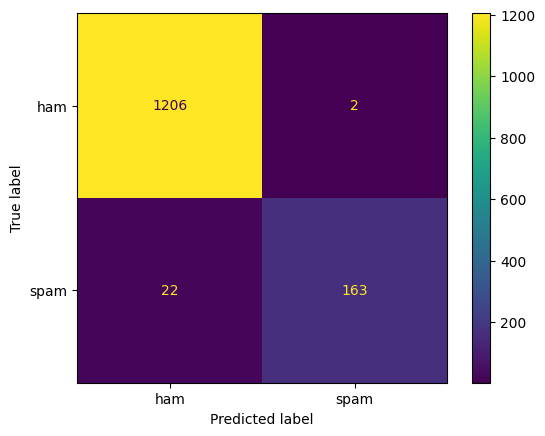

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.99      0.88      0.93       185

    accuracy                           0.98      1393
   macro avg       0.98      0.94      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [34]:
accuracy_score(y_test, y_pred)

0.9827709978463748

#### RBF Kernel - SVM

In [35]:
svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(x_train,y_train)
y_pred = svc_rbf.predict(x_test)
accuracy_score(y_test, y_pred)

0.9813352476669059

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       1.00      0.86      0.92       185

    accuracy                           0.98      1393
   macro avg       0.99      0.93      0.96      1393
weighted avg       0.98      0.98      0.98      1393



#### Polynomial Kernel - SVM

In [37]:
svc_pol = SVC(kernel='poly')
svc_pol.fit(x_train,y_train)
y_pred = svc_pol.predict(x_test)
accuracy_score(y_test, y_pred)

0.949748743718593

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.95      1.00      0.97      1208
        spam       1.00      0.62      0.77       185

    accuracy                           0.95      1393
   macro avg       0.97      0.81      0.87      1393
weighted avg       0.95      0.95      0.94      1393



#### Sigmoid Kernel - SVM

In [39]:
svc_sig = SVC(kernel='sigmoid')
svc_sig.fit(x_train,y_train)
y_pred = svc_sig.predict(x_test)
accuracy_score(y_test, y_pred)

0.9798994974874372

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1208
        spam       0.98      0.87      0.92       185

    accuracy                           0.98      1393
   macro avg       0.98      0.93      0.95      1393
weighted avg       0.98      0.98      0.98      1393



### Example - Prediction on Unknown Data

In [41]:
f = open('datasets/sample.csv')
lines = f.readlines()

In [42]:
lines

['Ok lar i double check wif da hair dresser already he said wun cut v short. He said will cut until i look nice.,,\n',
 'As a valued customer, I am pleased to advise you that following recent review of your Mob No. you are awarded with a £1500 Bonus Prize, call 09066364589\n',
 '"Today is ""song dedicated day.."" Which song will u dedicate for me? Send this to all ur valuable frnds but first rply me...",,\n']

In [43]:
new_lines = tfidf.transform(lines)

In [44]:
print(new_lines)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38 stored elements and shape (3, 5925)>
  Coords	Values
  (0, 159)	0.18077178036766892
  (0, 868)	0.19750424941724146
  (0, 1182)	0.492787979794336
  (0, 1192)	0.16647244794229585
  (0, 1428)	0.23381531545837836
  (0, 1451)	0.29057454644442504
  (0, 2202)	0.2304540596627735
  (0, 2824)	0.21117937982949003
  (0, 2957)	0.18864127087378907
  (0, 3557)	0.1430883040690324
  (0, 4345)	0.36897495252601237
  (0, 4547)	0.2548989299027367
  (0, 5495)	0.20764978723183164
  (0, 5708)	0.2232316789283425
  (0, 5819)	0.26612967620446176
  (1, 82)	0.368893820233138
  (1, 375)	0.2553162040803999
  (1, 603)	0.3007129751361382
  (1, 756)	0.14927734138755047
  (1, 1179)	0.25229753207149835
  (1, 1869)	0.3183376075553502
  (1, 3238)	0.29302543885055454
  (1, 3836)	0.2172251821997745
  (1, 3978)	0.23744406608144916
  (1, 4155)	0.332610393942441
  (1, 4254)	0.353409957427074
  (1, 5502)	0.30994748895200264
  (2, 1224)	0.1526849082307237
  (2, 1246

In [45]:
svc_lin.predict(new_lines)

array(['ham', 'spam', 'ham'], dtype=object)

#### Save the Model and Preprocessor

In [46]:
import joblib

In [47]:
joblib.dump(svc_lin, 'model.bin')

['model.bin']

In [48]:
joblib.dump(tfidf, 'preprocess.bin')

['preprocess.bin']